# Controlled patchy-particle emergence study

This laboratory asks one bounded question: **can finite-range, directional
particle rules produce observable structures at a scale larger than one
interaction?** It compares two initialization methods and two type-affinity
rules while holding the remaining physical parameters fixed.

The notebook analyzes a seeded HOOMD-blue ensemble. It is not a claim about a
universal thermodynamic phase, an atomistic material, or quantum mechanics.

## From local state to global observation

The complete microscopic state is

$$
X(t)=\bigl(s_1(t),\ldots,s_N(t)\bigr).
$$

Each particle reacts only through finite-range pair interactions and the local
walls. An external observer then applies two projections:

$$
X(t)\xrightarrow{\Pi_G}G_t=(V,E_t)
\xrightarrow{\Pi_M}
\bigl(S_{\max},\langle k\rangle,\Psi_2,U,K,T_{\mathrm{kin}}\bigr)_t.
$$

The first projection produces an instantaneous contact graph. The second
produces macroscopic measurements. Neither projection is fed back into the
simulation, so observation does not become centralized control.

## Microscopic model

Particles have one, two, or three body-fixed patch directions. The conservative
energy is

$$
U(X)=\sum_{i<j}
\left[U_{\mathrm{WCA}}(r_{ij})
+U_{\mathrm{patch}}(r_{ij},q_i,q_j)\right]
+\sum_iU_{\mathrm{wall}}(\mathbf x_i).
$$

The WCA core resists overlap. A shifted radial Gaussian, multiplied by HOOMD's
angular patch masks, provides directional attraction and torque. Translation
follows Langevin dynamics,

$$
m\frac{d\mathbf v_i}{dt}
=\mathbf F_i^{\mathrm C}-\gamma\mathbf v_i+\mathbf F_i^{\mathrm R},
\qquad
\frac{d\mathbf x_i}{dt}=\mathbf v_i,
$$

with an analogous rotational equation. The heat bath therefore exchanges
energy with the particles; $U+K$ is not expected to be conserved.

## Experimental design

The controlled $2\times2$ design is

$$
\{\text{random},\text{blue-noise}\}
\times
\{\text{uniform},\text{selective}\}.
$$

Each condition is repeated for three seeds. The initialization axis tests
whether accidental initial crowding changes the observation. The chemistry
axis tests whether a symmetric type-pair attraction matrix changes assembly.
Particle counts, density, temperature, timestep, patch geometry, barriers,
and run length are shared by all conditions.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display


def find_project(start: Path) -> Path:
    start = start.resolve()
    for root in (start, *start.parents):
        direct = root if (root / "study.toml").exists() else None
        nested = root / "experiments" / "emergence" / "hoomd"
        if direct is not None:
            return direct
        if (nested / "study.toml").exists():
            return nested
    raise FileNotFoundError("Could not locate the HOOMD study project.")


PROJECT = find_project(Path.cwd())
OUTPUT = PROJECT / "outputs" / "study"
RUNS = pd.read_csv(OUTPUT / "runs.csv")
CONDITIONS = pd.read_csv(OUTPUT / "conditions.csv")
print(f"project: {PROJECT}")
print(f"runs: {len(RUNS)}")

project: storage/projects/code/local/patchy-particle-emergence/hoomd
runs: 12


In [2]:
columns = [
    "condition",
    "runs",
    "maximum_largest_component_fraction_mean",
    "maximum_largest_component_fraction_sd",
    "tail_largest_component_fraction_mean",
    "tail_largest_component_fraction_sd",
    "tail_mean_degree_mean",
    "tail_orientational_order_mean",
]
CONDITIONS[columns].round(4)

,condition,runs,maximum_largest_component_fraction_mean,maximum_largest_component_fraction_sd,tail_largest_component_fraction_mean,tail_largest_component_fraction_sd,tail_mean_degree_mean,tail_orientational_order_mean
0,random--uniform,3,0.1076,0.0159,0.0563,0.0062,0.6018,0.1029
1,random--selective,3,0.1597,0.0628,0.0880,0.0343,0.7138,0.1012
2,blue-noise--uniform,3,0.1042,0.0104,0.0531,0.0042,0.6095,0.1167
3,blue-noise--selective,3,0.1528,0.0060,0.0675,0.0107,0.6617,0.0958


## Structural projection

The simulation has continuous particle state. For analysis, every saved frame
is projected into a contact graph $G_t=(V,E_t)$. An edge is inferred only when
two particles are near and mutually patch-aligned. From this graph we measure

$$
S_{\max}(t)=\frac{\max_{C\in\operatorname{CC}(G_t)}|C|}{|V|},
\qquad
\langle k\rangle_t=\frac{2|E_t|}{|V|}.
$$

$S_{\max}$ measures the largest connected structure; mean degree measures its
local connectivity. These are analysis observables, not permanent HOOMD bonds.

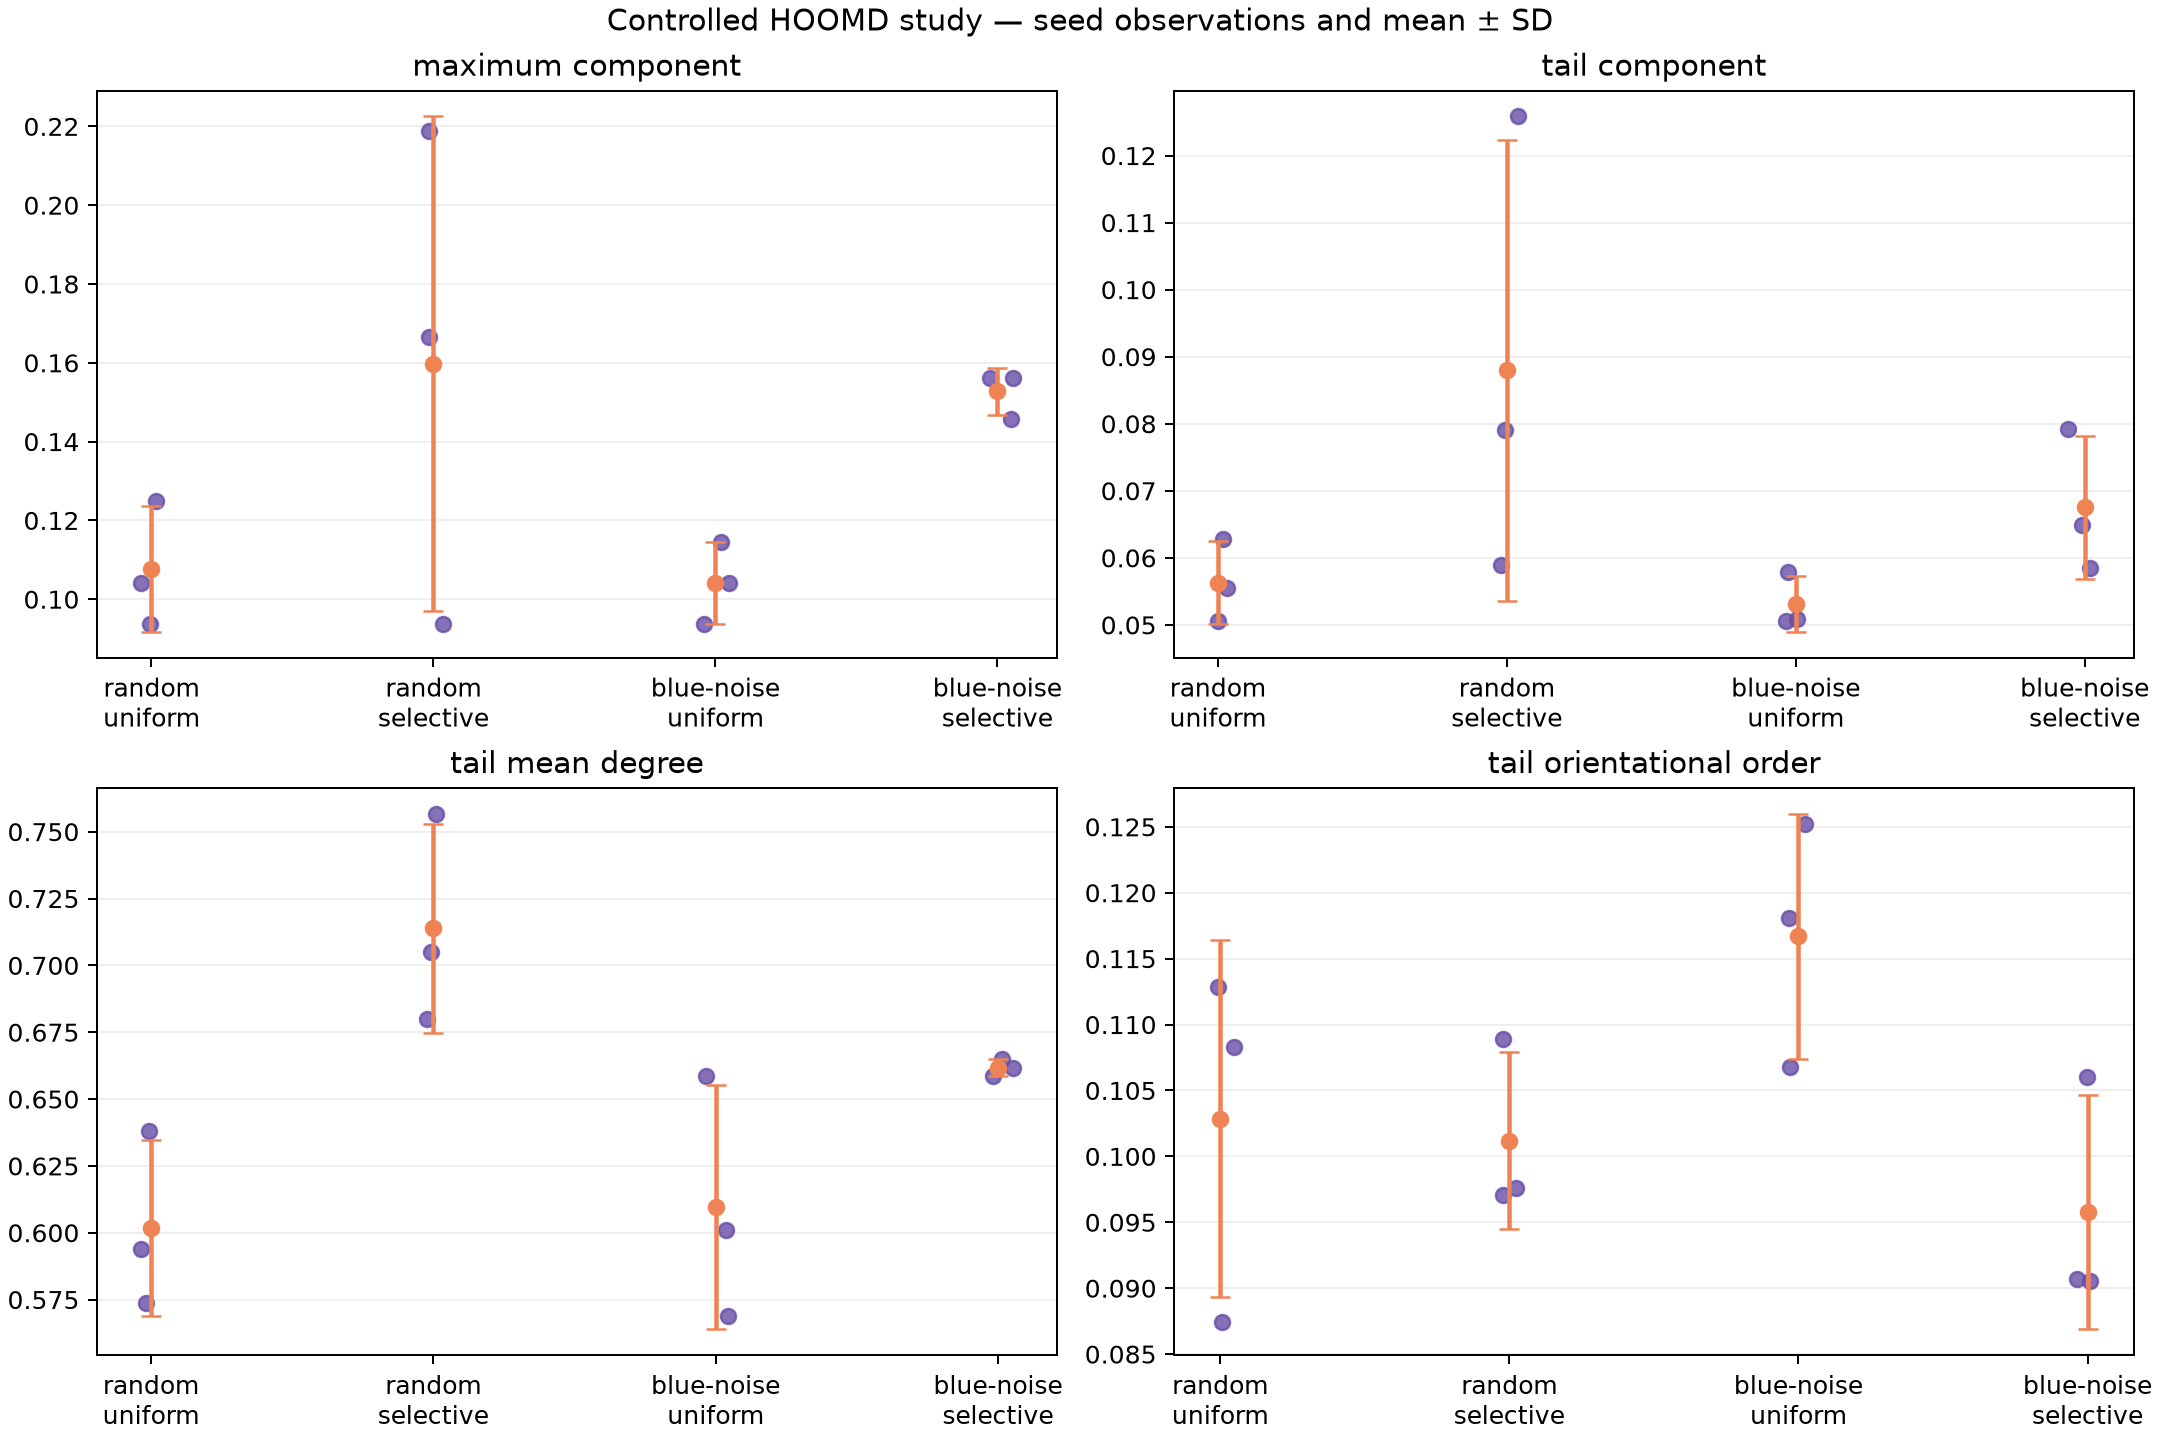

In [3]:
display(Image(filename=str(OUTPUT / "report" / "condition-comparison.png"), width=1000))

## Representative peak structures

For each condition, the panel below uses the seed whose maximum component is
the median of the three seed maxima. The displayed frame is that run's peak,
not a hand-selected final state. Purple outlines and edges identify the
largest inferred contact component.

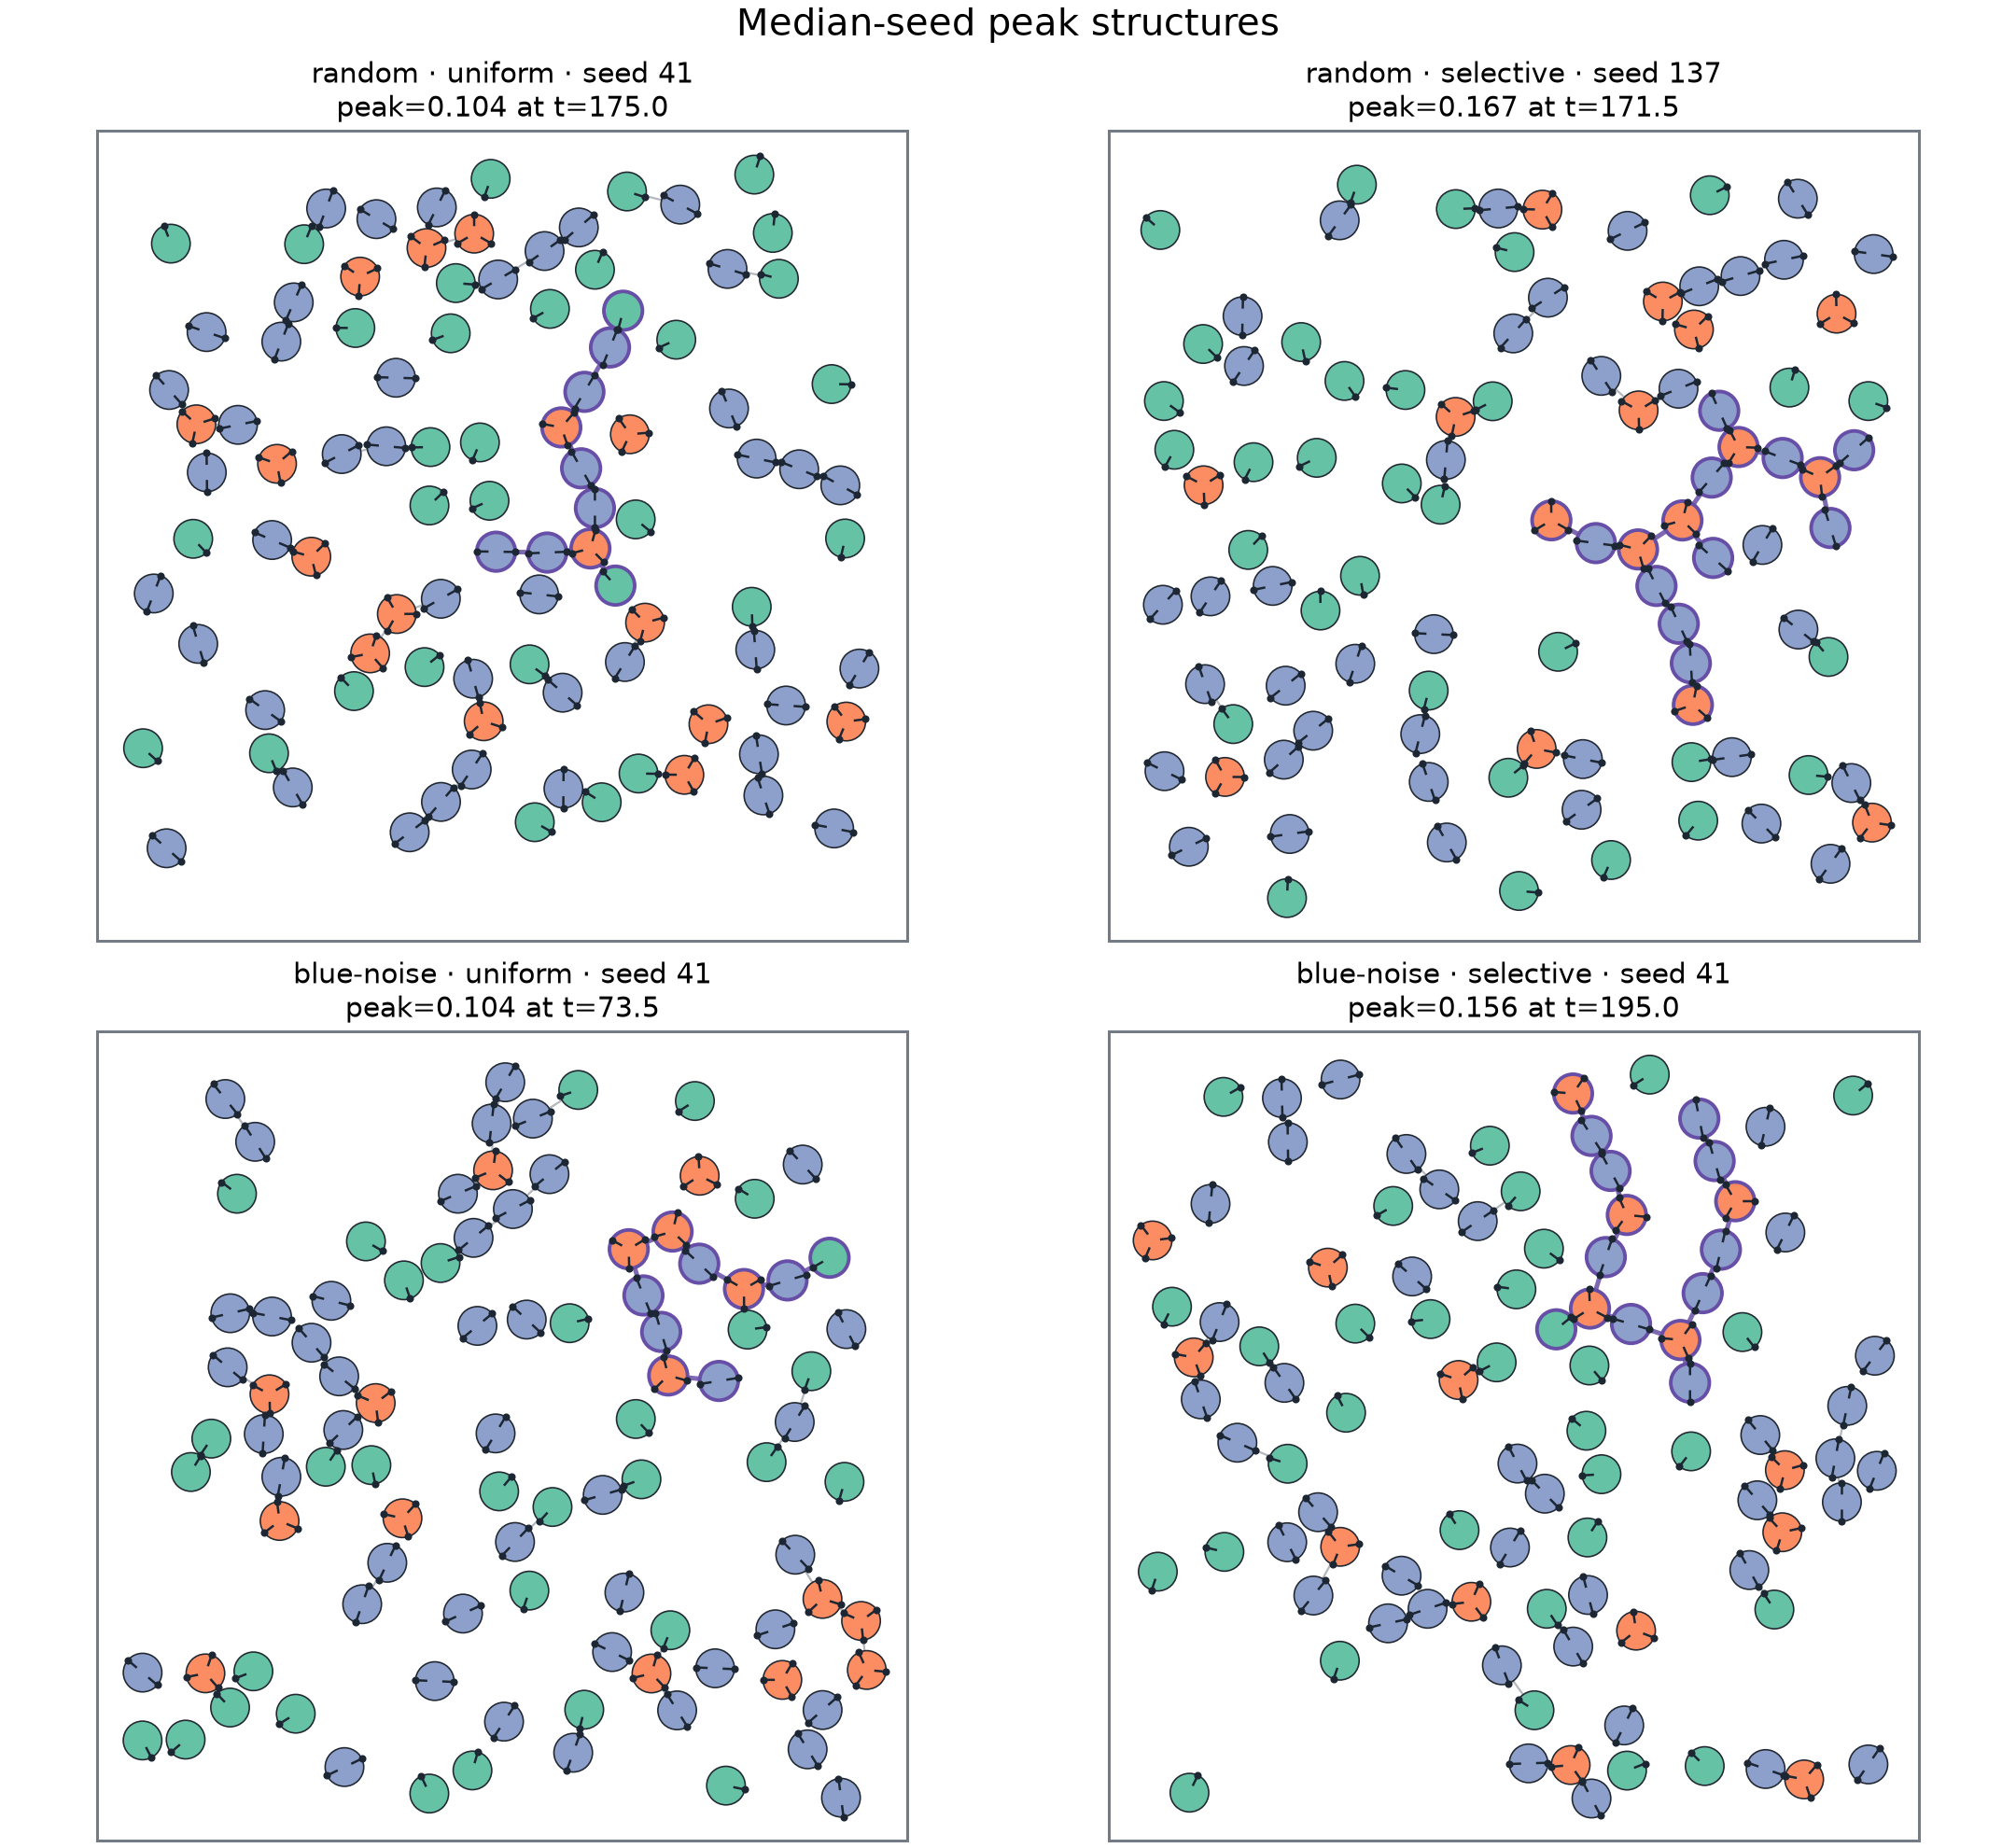

In [4]:
display(Image(filename=str(OUTPUT / "report" / "peak-structures.png"), width=1000))

## Energetic context

Potential energy $U$ and kinetic energy $K$ provide context for structural
change. Because the system uses a Langevin thermostat, neither quantity is
expected to remain constant: the bath exchanges energy with the particles.
The measured kinetic temperature should instead fluctuate around the declared
target.

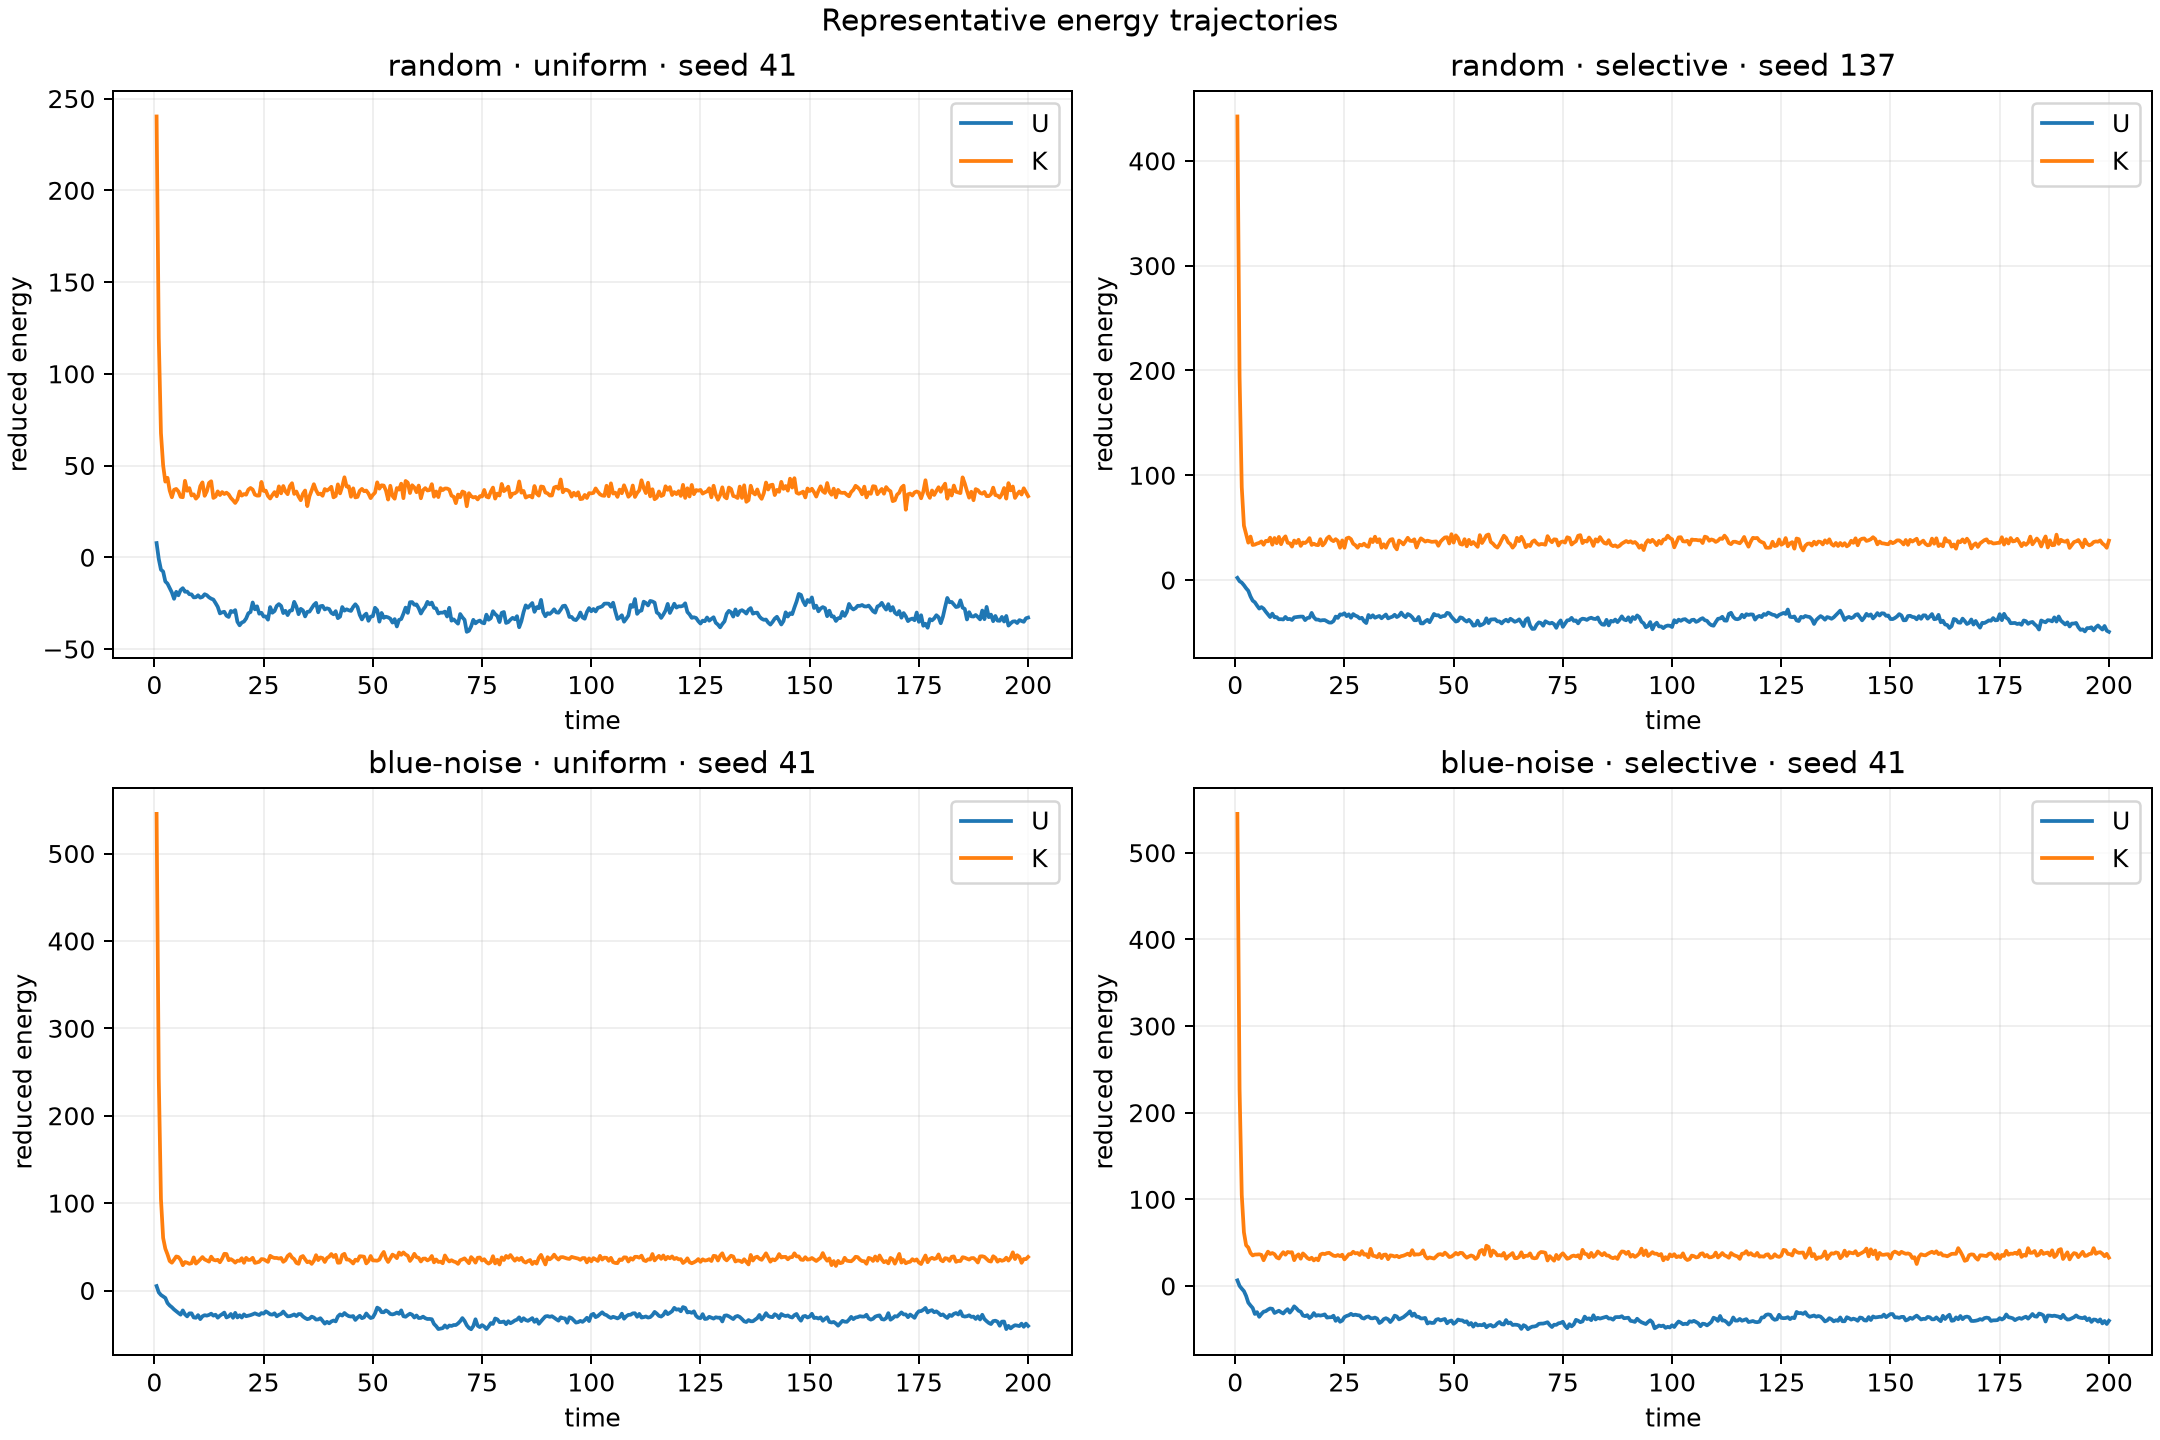

In [5]:
display(Image(filename=str(OUTPUT / "report" / "energy-comparison.png"), width=1000))

In [6]:
target_temperature = 0.25
temperature_check = CONDITIONS[["condition", "tail_kinetic_temperature_mean"]].copy()
temperature_check["difference_from_target"] = (
    temperature_check["tail_kinetic_temperature_mean"] - target_temperature
)
temperature_check.round(4)

,condition,tail_kinetic_temperature_mean,difference_from_target
0,random--uniform,0.2515,0.0015
1,random--selective,0.2508,0.0008
2,blue-noise--uniform,0.2498,-0.0002
3,blue-noise--selective,0.2515,0.0015


## What this ensemble supports

Within this finite experiment, selective type affinity increased the observed
peak connected fraction relative to uniform affinity for both initialization
methods. The blue-noise/selective condition had the most consistent peak
across the three seeds, while the random/selective condition had the greatest
seed variance and the highest single-run peak. Selective conditions also had
more negative mean tail potential energy.

The evidence therefore supports a modest statement: **changing only the local
type-affinity rule changed the distribution of finite structural observables**.
It does not yet establish a stable bulk phase, asymptotic scaling law, or
universality class. Three seeds and one finite system size are an exploratory
ensemble; larger seed counts, sizes, durations, and timestep checks belong to
a later study.

## Reproduction contract

Run `pixi run study` from the HOOMD experiment directory. Every run stores its
fully resolved TOML configuration and SHA-256 checksum beside the trajectory
and observables. Run `pixi run notebook-execute` afterward to refresh this
notebook from those outputs.